<h1><font color="#113D68" size=6>Actividad Semana 1</font></h1>
<h2><font color="#113D68" size=6>Análisis problema de clasificación con Deep Learning</font></h2>


<br><br>
<div style="text-align: right">
<font size=3>Daniel González</font><br>
<font size=3>Semana 1: Redes convolucionales y otros tipos de redes</font><br>
<font size=3>IEBS</font>
</div>

---


<h3>Alumno</h3>
Adrián Robles Arques

In [2]:
import tensorflow as tf
import numpy as np

# Para mostrar gráficas
import matplotlib.pyplot as plt
%matplotlib inline

# Anaconda fixing problem
#import os
#os.environ['KMP_DUPLICATE_LIB_OK']='True'

En esta actividad vamos a seguir familiarizándonos con la herramienta *TensorFlow* pero esta vez para redes convolucionales, para ello seguiremos utilizando el dataset de imágenes a color visto en clase.

<a id="section2"></a>
# <font color="#004D7F" size=5>CIFAR10 dataset</font>

Este dataset es el que hemos visto en la clase anterior y con el que trabajaremos en el caso práctico. Para refrescarlo, es un dataset que contiene imágenes en color de objetos que tenemos que clasificar.

El dataset de de imágenes CIFAR10 tiene las siguintes características:
- Imágenes de 10 tipos de objetos: aviones, automóbiles, pájaros, gatos, ciervos, perros, ranas, caballos, barcos y camiones.
- Imágenes en color, es decir, cada pixel tiene 3 valores entre 0 y 255, esos valores corresponden a los valores de RGB (Red, Green, Blue).
- Imágenes de tamaño 32x32x3, 32x32 píxeles y 3 valores por pixel.
- 50.000 imágenes para el entrenamiento y 10.000 imágenes para el test.

<br><br>
<img src="https://drive.google.com/uc?id=1vVu275LEOyQCbw9x1f8ygfAhxS3PK_Zl" align="center" width="400">

## <font color="#004D7F" size=4>Ejercicio 1</font>
Para empezar debemos descargar los datos de las bases de datos de Tensorflow.

Carga los datos como hemos visto en clase:

In [3]:
# Cargar los datos de CIFAR-10
from tensorflow.keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Creamos un diccionario para las etiquetas
Label_dict = {
0: 	'airplane',
1: 	'automobile',
2: 	'bird',
3: 	'cat',
4: 	'deer',
5: 	'dog',
6: 	'frog',
7: 	'horse',
8: 	'ship',
9: 	'truck'}

170500096/170498071 [==============================] - 21s 0us/step


Normaliza los datos:

In [4]:
# Normalizamos los datos de las imágenes
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0


Familiarízate con el dataset accediendo a los elementos, viendo los tamaños, los valores, etc.

In [ ]:
# Vamos a mostrar los tamaños de los conjuntos de imágenes
print(X_train.shape)
print(X_test.shape)


(50000, 32, 32, 3)
(10000, 32, 32, 3)


Aquí vemos que en cada conjunto tenemos el tamaño del conjunto (50000 para el conjunto de entrenamiento y 10000 en el de validación), el tamaño de cada imagen (32*32) y el número de canales (3 canales dado que son imágenes RGB)

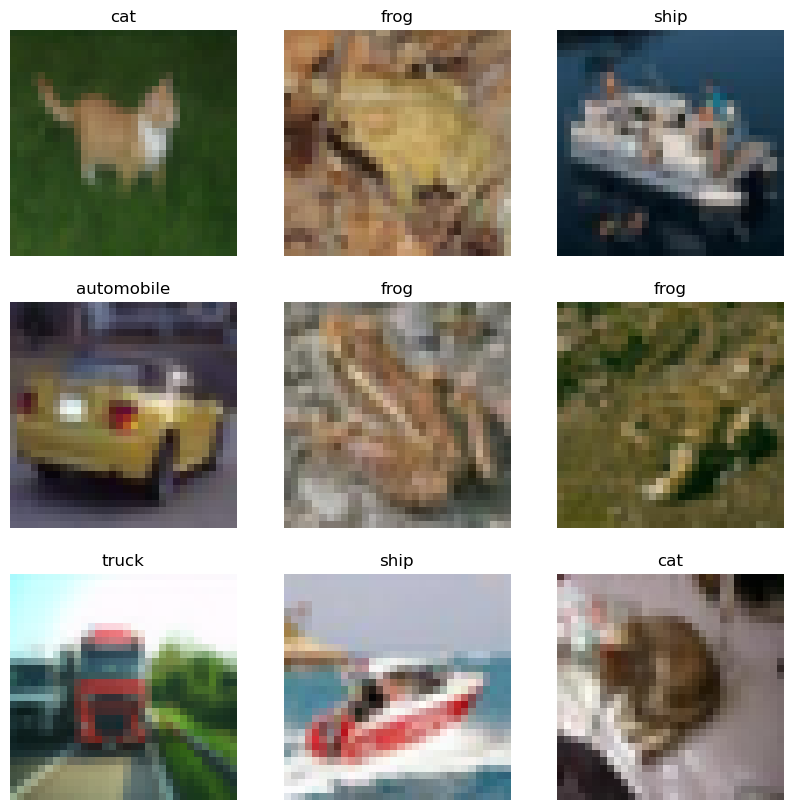

In [ ]:
# Mostramos un conjunto de imágenes aleatorias de entrenamiento
plt.figure(figsize=(10, 10))
for i in range(9):
    index = np.random.randint(0, len(X_train))
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[index])
    plt.title(Label_dict[y_train[index][0]])
    plt.axis('off')
plt.show()

<a id="section4"></a>
# <font color="#004D7F" size=5>Experimentos con CNNs</font>
A continuación, realiza 2 experimentos usando redes convolucionales con las redes que se te indican en cada sección.

<a id="section4.1"></a>
# <font color="#004D7F" size=4>Ejercicio 2</font>

Arquitectura de la red:

- Capa convolucional `Conv2D` con 16 filtros/kernels de tamaño `(3,3)`, padding con relleno, activación *ReLU* y con entrada `(32,32,3)`
- Capa pooling `MaxPool2D` con reducción de 2 tanto en tamaño como en desplazamiento (stride) y padding con relleno.
- Capa de aplanado `Flatten`.
- Capa densa `Dense` con 64 neuronas y función de activación _ReLU_.
- Capa densa `Dense` con 32 neuronas y función de activación _ReLU_.
- Capa de salida densa `Dense` con 10 neuronas y función de activación _Softmax_.

Configuración del entrenamiento:

- Optimizador: Adam con factor de entrenamiento 0.0001
- Función de error: `sparce_categorical_crossentropy`.
- Métricas: `accuracy`.
- Número de _epochs_: 10

In [14]:
# Importamos las librerías necesarias para crear la red neuronal convolucional
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

# Definimos la arquitectura de la red neuronal convolucional
model = Sequential([
    Conv2D(16, (3, 3),padding='same' ,activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2), strides=2, padding='same'),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(34, activation='relu'),
    Dense(10, activation='softmax')
])

In [15]:
# Compilamos el modelo
model.compile(optimizer=Adam(learning_rate=1e-4),
            loss=SparseCategoricalCrossentropy(from_logits=False),
            metrics=['accuracy'])

In [23]:
# Mostramos un resumen del modelo
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 32, 32, 16)        448       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 16, 16, 16)        0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 4096)              0         
_________________________________________________________________
dense_3 (Dense)              (None, 64)                262208    
_________________________________________________________________
dense_4 (Dense)              (None, 34)                2210      
_________________________________________________________________
dense_5 (Dense)              (None, 10)                350       
Total params: 265,216
Trainable params: 265,216
Non-trainable params: 0
________________________________________________

Evalua el modelo con el conjunto de test y muestra en una gráfica la evolución del entrenamiento:

Epoch 1/10
1563/1563 [==============================] - 5s 4ms/step - loss: 1.9584 - accuracy: 0.3032 - val_loss: 1.7423 - val_accuracy: 0.3934
Epoch 2/10
1563/1563 [==============================] - 5s 3ms/step - loss: 1.6623 - accuracy: 0.4167 - val_loss: 1.5717 - val_accuracy: 0.4449
Epoch 3/10
1563/1563 [==============================] - 5s 3ms/step - loss: 1.5272 - accuracy: 0.4634 - val_loss: 1.4650 - val_accuracy: 0.4834
Epoch 4/10
1563/1563 [==============================] - 5s 3ms/step - loss: 1.4361 - accuracy: 0.4926 - val_loss: 1.4066 - val_accuracy: 0.4943
Epoch 5/10
1563/1563 [==============================] - 5s 3ms/step - loss: 1.3744 - accuracy: 0.5126 - val_loss: 1.3630 - val_accuracy: 0.5085
Epoch 6/10
1563/1563 [==============================] - 5s 3ms/step - loss: 1.3262 - accuracy: 0.5304 - val_loss: 1.3248 - val_accuracy: 0.5302
Epoch 7/10
1563/1563 [==============================] - 5s 3ms/step - loss: 1.2881 - accuracy: 0.5459 - val_loss: 1.2846 - val_accuracy:

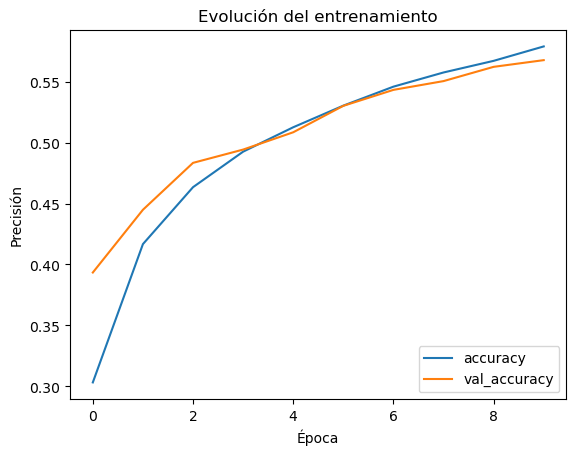

In [16]:
# Entrenamos el modelo y asignamos los datos de entrenamiento y validación
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

# Graficamos la evolución del entrenamiento
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.title('Evolución del entrenamiento')
plt.legend(loc='lower right')
plt.show()


Escribe un pequeño texto sacando conclusiones de los resultado obtenidos:

A la luz de la gráfica que nos muestra la evolución de la precisión de la clasificación, o esta red es demasiado simple para la tarea asignada, o bien se está entrenando poco tiempo. La evolución parece adecuada, dado que la distancia entre la curva de entrenamiento y la curva de validación es muy pequeña. Sin embargo se observa que claramente puede mejorar aún más su resultado, ya que la curva no parece haberse estancado aún, lo que nos indica que nuestra red aún no ha convergido a una solución óptima.

<a id="section4.2"></a>
# <font color="#004D7F" size=4>Ejercicio 3</font>

Arquitectura de la red:

- Capa convolucional `Conv2D` con 32 filtros/kernels de tamaño `(3,3)`, padding con relleno, activación *ReLU* y con entrada `(32,32,3)`
- Capa pooling `MaxPool2D` con reducción de 2 tanto en tamaño como en desplazamiento (stride) y padding con relleno.
- Capa convolucional `Conv2D` con 64 filtros/kernels de tamaño `(3,3)`, padding con relleno y activación *ReLU*
- Capa pooling `MaxPool2D` con reducción de 2 tanto en tamaño como en desplazamiento (stride) y padding con relleno.
- Capa convolucional `Conv2D` con 64 filtros/kernels de tamaño `(3,3)`, padding con relleno y activación *ReLU*
- Capa pooling `MaxPool2D` con reducción de 2 tanto en tamaño como en desplazamiento (stride) y padding con relleno.
- Capa de aplanado `Flatten`.
- Capa densa `Dense` con 64 neuronas y función de activación _ReLU_.
- Capa de salida densa `Dense` con 10 neuronas y función de activación _Softmax_.

Configuración del entrenamiento:

- Optimizador: Adam con factor de entrenamiento 0.001
- Función de error: `sparce_categorical_crossentropy`.
- Métricas: `accuracy`.
- Número de _epochs_: 20

In [18]:
# Definimos la arquitectura de la red
model2 = Sequential([
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2), strides=2, padding='same'),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2), strides=2, padding='same'),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2), strides=2, padding='same'),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Compilamos el modelo
model2.compile(optimizer=Adam(learning_rate=1e-3),
                loss=SparseCategoricalCrossentropy(from_logits=False),
                metrics=['accuracy'])

In [22]:
# Mostramos un resumen del modelo
model2.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_2 (Conv2D)            (None, 32, 32, 32)        896       
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 16, 16, 32)        0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 16, 16, 64)        18496     
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 8, 8, 64)          0         
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 8, 8, 64)          36928     
_________________________________________________________________
max_pooling2d_4 (MaxPooling2 (None, 4, 4, 64)          0         
_________________________________________________________________
flatten_2 (Flatten)          (None, 1024)             

In [19]:
# Entrenamos el modelo, asignando los datos de validación
history2 = model2.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test))

Epoch 1/20
1563/1563 [==============================] - 15s 10ms/step - loss: 1.5016 - accuracy: 0.4525 - val_loss: 1.2084 - val_accuracy: 0.5688
Epoch 2/20
1563/1563 [==============================] - 15s 10ms/step - loss: 1.0616 - accuracy: 0.6232 - val_loss: 0.9839 - val_accuracy: 0.6582
Epoch 3/20
1563/1563 [==============================] - 15s 10ms/step - loss: 0.9054 - accuracy: 0.6822 - val_loss: 0.9209 - val_accuracy: 0.6747
Epoch 4/20
1563/1563 [==============================] - 15s 9ms/step - loss: 0.8126 - accuracy: 0.7185 - val_loss: 0.9014 - val_accuracy: 0.6936
Epoch 5/20
1563/1563 [==============================] - 15s 10ms/step - loss: 0.7399 - accuracy: 0.7407 - val_loss: 0.8332 - val_accuracy: 0.7141
Epoch 6/20
1563/1563 [==============================] - 15s 10ms/step - loss: 0.6825 - accuracy: 0.7608 - val_loss: 0.8333 - val_accuracy: 0.7192
Epoch 7/20
1563/1563 [==============================] - 15s 10ms/step - loss: 0.6311 - accuracy: 0.7808 - val_loss: 0.8300 - 

Evalua el modelo con el conjunto de test y muestra en una gráfica la evolución del entrenamiento:

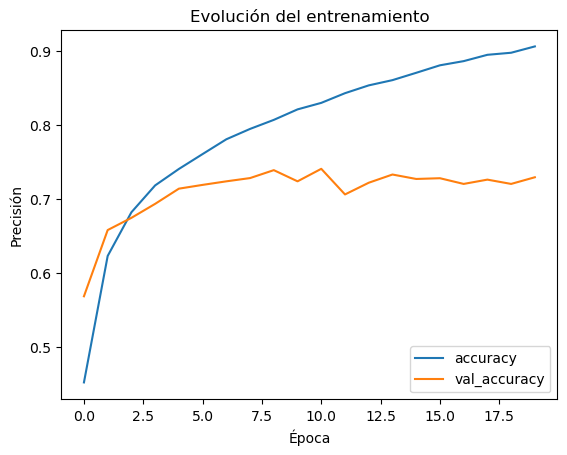

In [21]:
# Representamos la gráfica de la evolución del entrenamiento
plt.plot(history2.history['accuracy'], label='accuracy')
plt.plot(history2.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.title('Evolución del entrenamiento')
plt.legend(loc='lower right')
plt.show()

Escribe un pequeño texto sacando conclusiones de los resultado obtenidos:

Este modelo, a juzgar por los resultados mostrados en la gráfica de evolución del entrenamiento, vemos que está incurriendo en sobreentrenamiento. Esto seguramente se deba a que la arquitectura del modelo es demasiado compleja para la tarea requerida. Vemos que a partir de cierto punto la precisión del conjunto de evaluación se estanca o incluso desciende, mientras que la curva de entrenamiento sigue creciendo. 

# <font color="#004D7F" size=3>Ejercicio 4</font>
Una vez realizado todos los experimentos anteriores, ¿qué modelo elegirías para desplegar en producción? ¿Por qué? 

Explica en breves palabras qué modelo eligirías para desplegar en producción y porqué. Compara cada experimento y extráe tus propias conclusiones.

De los dos modelos entrenados, el que parece alcanzar un mejor resultado en la métrica de validación es el segundo, aunque ciertamente el primero es más sencillo y no ha llegado a converger, si probamos con más epochs de entrenamiento, éste modelo llega a converger en torno al 60 - 65% de precisión. Sin embargo, el segundo modelo es capaz de mejorar este resultado, convergiendo en torno al 70% de precisión. Podemos añadir un pequeño Dropout para comprobar si mejora el modelo, evitando el sobreajuste.

In [ ]:
# Importamos un early stopping para evitar el sobreajuste
from keras.callbacks import EarlyStopping

# Definimos el early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, mode='auto', verbose=1)

# Copiamos la arquitectura del primer modelo
model_prod = Sequential([
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2), strides=2, padding='same'),
    Dropout(0.2),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2), strides=2, padding='same'),
    Dropout(0.2),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2), strides=2, padding='same'),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Compilamos el modelo
model_prod.compile(optimizer=Adam(learning_rate=1e-3),
            loss=SparseCategoricalCrossentropy(from_logits=False),
            metrics=['accuracy'])

# Entrenamos el modelo
history_prod = model_prod.fit(X_train, y_train, epochs=50, batch_size=50 ,validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)  

Epoch 1/50
1563/1563 [==============================] - 18s 11ms/step - loss: 1.5570 - accuracy: 0.4344 - val_loss: 1.2295 - val_accuracy: 0.5680
Epoch 2/50
1563/1563 [==============================] - 17s 11ms/step - loss: 1.1620 - accuracy: 0.5863 - val_loss: 1.0316 - val_accuracy: 0.6350
Epoch 3/50
1563/1563 [==============================] - 17s 11ms/step - loss: 1.0025 - accuracy: 0.6454 - val_loss: 0.9042 - val_accuracy: 0.6822
Epoch 4/50
1563/1563 [==============================] - 17s 11ms/step - loss: 0.9150 - accuracy: 0.6788 - val_loss: 0.9214 - val_accuracy: 0.6727
Epoch 5/50
1563/1563 [==============================] - 17s 11ms/step - loss: 0.8533 - accuracy: 0.6996 - val_loss: 0.8505 - val_accuracy: 0.7060
Epoch 6/50
1563/1563 [==============================] - 17s 11ms/step - loss: 0.8086 - accuracy: 0.7166 - val_loss: 0.8130 - val_accuracy: 0.7249
Epoch 7/50
1563/1563 [==============================] - 17s 11ms/step - loss: 0.7748 - accuracy: 0.7302 - val_loss: 0.8017 -

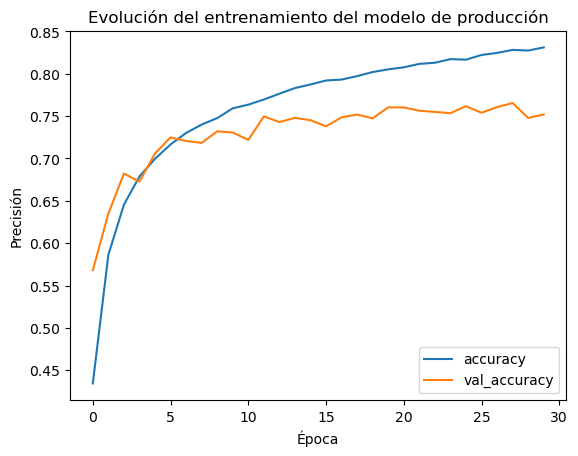

In [45]:
# Graficamos la evolución del entrenamiento
plt.plot(history_prod.history['accuracy'], label='accuracy')
plt.plot(history_prod.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.title('Evolución del entrenamiento del modelo de producción')
plt.legend(loc='lower right')
plt.show()

Como vemos, introduciendo un dropout entre las capas convolucionales logramos evitar el sobreajuste de la red y mejorar la precisión del modelo, que ha pasado del 72% al 75%.